# Time-Dependent S21 Measurement Data Handling

This notebook performs the following steps:
1. **Organize & Rename** raw sweep CSV files -> 3-column CSV files
2. **Trim** visually identify the stable onset and discard early sweeps (it is usually happened when the temperature is not actually stable but the measurement starts performing.)
3. **Fit** each sweep with the DCM circle fit to extract Qi, Qc, fc
4. **PSD analysis** of the fit parameters using Welch's method

## Section 0 — Imports & Path Setup

In [1]:
import sys
import re
import shutil
from pathlib import Path
from datetime import datetime
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy import signal as sig

matplotlib.rcParams['figure.dpi'] = 100

# Point this to the local clone of Fitting_Code_Lab_2.0 
FITTING_CODE_DIR = Path(r"C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0")

sys.path.insert(0, str(FITTING_CODE_DIR / "helper_scripts"))
sys.path.insert(0, str(FITTING_CODE_DIR / "scresonators"))

import helper_fit as hf

print("All imports successful.")

helper_fit loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\helper_scripts\helper_fit.py
helper_misc loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\helper_scripts\helper_misc.py
fit_resonator.resonator loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\resonator.py
fit_resonator.fit loaded from: C:\Users\user\Documents\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\fit.py
All imports successful.


## Section 1 — Organize Measured Files

**Input** – a flat source directory containing CSV VNA sweep files directly, e.g.:
```
QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0.csv       <- 3-col, with header
QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0_full.csv  <- 13-col, with measurement details, skip the files later
QSD_CPW_w6g3_03_5p608GHz_-40dBm_15mK_0.csv
...
```

The CSV files already contain the 3 columns required by the fitting code
(Frequency Hz, S21 magn_dB, S21 phase_deg) with a header row.

**Output** – organized folder `{target_dir}/{res_label}_{freq_str}/`
with the same files copied in plus a `metadata.csv`.

In [2]:
# User Configuration
source_dir = Path(r"C:\Users\user\Downloads\15mK_Time_Dependent_S21\15mK_Time_Dependent_S21\06_10_174033")
target_dir = Path(r"C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03")
res_label  = "Resonator_1"

if not source_dir.exists():
    raise FileNotFoundError(f"Source directory not found: {source_dir}")
print(f"Source dir : {source_dir}")
print(f"Target dir : {target_dir}")
print(f"Resonator  : {res_label}")

Source dir : C:\Users\user\Downloads\15mK_Time_Dependent_S21\15mK_Time_Dependent_S21\06_10_174033
Target dir : C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03
Resonator  : Resonator_1


In [3]:
# Helper: parse the new filename format
#
# Expected stem: {sample_name}_{freq_str}_{power_str}_{temperature}_{index}
# Example      : QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0
#
# The regex anchors on the known-format suffix and lets sample_name float.
# _full files are excluded naturally because their stem ends with '_full',
# not a digit, so the regex simply does not match them.

_FILE_RE = re.compile(
    r'^(.+?)_([ \dp]+GHz)_([-\dp]+dBm)_(\w+?)_(\d+)$'
)

def parse_sweep_file(stem: str) -> dict | None:
    """Parse a sweep CSV stem. Returns None for non-matching names (_full etc.)."""
    m = _FILE_RE.match(stem)
    if not m:
        return None
    sample, freq_str, power_str, temperature, idx = m.groups()
    return {
        'sample_name' : sample,
        'freq_str'    : freq_str,
        'power_str'   : power_str,
        'temperature' : temperature,
        'file_index'  : int(idx),
    }

print("Helper function defined.")

# Quick self-test
_test_cases = [
    ("QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0",      True),
    ("QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0_full", False),
]
for stem, expect_match in _test_cases:
    result = parse_sweep_file(stem)
    ok = (result is not None) == expect_match
    print(f"  {'OK' if ok else 'FAIL'}  '{stem}' -> {result}")

Helper function defined.
  OK  'QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0' -> {'sample_name': 'QSD_CPW_w6g3_03', 'freq_str': '5p608GHz', 'power_str': '-20dBm', 'temperature': '15mK', 'file_index': 0}
  OK  'QSD_CPW_w6g3_03_5p608GHz_-20dBm_15mK_0_full' -> None


In [4]:
# Scan all CSV files in the flat source directory

sweep_entries = []
skipped       = []

for csv_path in sorted(source_dir.glob("*.csv")):
    info = parse_sweep_file(csv_path.stem)
    if info is None:
        skipped.append(csv_path.name)   # _full files land here
        continue
    info['csv_path']  = csv_path
    info['mtime']     = csv_path.stat().st_mtime
    sweep_entries.append(info)

print(f"Matched sweep CSVs : {len(sweep_entries)}")
print(f"Skipped (e.g. _full): {len(skipped)}")

# Verify a single center frequency
all_freq_strs = set(e['freq_str'] for e in sweep_entries)
if len(all_freq_strs) != 1:
    print(f"[WARNING] Multiple frequencies found: {all_freq_strs}")
    from collections import Counter
    freq_str = Counter(e['freq_str'] for e in sweep_entries).most_common(1)[0][0]
    sweep_entries = [e for e in sweep_entries if e['freq_str'] == freq_str]
else:
    freq_str = all_freq_strs.pop()
print(f"Center frequency   : {freq_str}")

# Also extract sample_name and temperature from the parsed files
sample_name = sweep_entries[0]['sample_name']
temperature = sweep_entries[0]['temperature']
print(f"Sample name        : {sample_name}")
print(f"Temperature        : {temperature}")

# Group by power, sort each group by file_index
power_groups = defaultdict(list)
for e in sweep_entries:
    power_groups[e['power_str']].append(e)

all_powers = sorted(power_groups.keys(), key=lambda p: float(p.replace('dBm', '')))

print(f"\nPowers found: {all_powers}")
for pwr in all_powers:
    g = sorted(power_groups[pwr], key=lambda e: e['file_index'])
    power_groups[pwr] = g
    print(f"  {pwr:>10s} : {len(g):>5d} sweeps  "
          f"(index {g[0]['file_index']:04d} → {g[-1]['file_index']:04d})")

Matched sweep CSVs : 390
Skipped (e.g. _full): 391
Center frequency   : 4p613GHz
Sample name        : HTCav_01_CPW_w50g25_03
Temperature        : 15mK

Powers found: ['-60dBm', '-40dBm', '-20dBm']
      -60dBm :   130 sweeps  (index 0000 → 0129)
      -40dBm :   130 sweeps  (index 0000 → 0129)
      -20dBm :   130 sweeps  (index 0000 → 0129)


In [5]:
# ── Copy files to organized directory & build metadata ───────────────────────
#
# Files are already in the correct 3-column format (with header).
# scresonators header_parse skips non-numeric header rows automatically.
# We re-index from 0 within each power group to guarantee a clean sequence.

organized_dir = target_dir / f"{res_label}_{freq_str}"
organized_dir.mkdir(parents=True, exist_ok=True)

metadata_rows = []

for pwr in all_powers:
    for new_idx, entry in enumerate(power_groups[pwr]):
        new_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{new_idx}.csv"
        dst      = organized_dir / new_name
        shutil.copy2(entry['csv_path'], dst)

        metadata_rows.append({
            'power_str'    : pwr,
            'file_index'   : new_idx,
            'orig_index'   : entry['file_index'],
            'mtime'        : entry['mtime'],
            'filename'     : new_name,
        })

meta_df = pd.DataFrame(metadata_rows)
meta_df.to_csv(organized_dir / "metadata.csv", index=False)

print(f"Organized files saved to: {organized_dir}")
print(f"Total files copied      : {len(metadata_rows)}")
print()
print(meta_df.groupby('power_str')['file_index'].count().rename('n_sweeps').to_string())

Organized files saved to: C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\Resonator_1_4p613GHz
Total files copied      : 390

power_str
-20dBm    130
-40dBm    130
-60dBm    130


In [6]:
# ── Estimate sweep duration from file modification times ─────────────────────
#
# mtime of each CSV ≈ time the measuring script finished writing that sweep.
# sweep_duration = median Δt between consecutive files of the same power.

dt_samples = []
for pwr in all_powers:
    mtimes = np.array([e['mtime'] for e in power_groups[pwr]])
    if len(mtimes) >= 2:
        dt_samples.extend(np.diff(mtimes).tolist())

sweep_duration = float(np.median(dt_samples))
print(f"Estimated sweep duration : {sweep_duration:.3f} s  ({sweep_duration/60:.2f} min)")
print(f"Sampling frequency (1/Δt): {1/sweep_duration:.4f} Hz")
print()
print("If this looks wrong (e.g. files were copied after measurement),")
print("override manually:  sweep_duration = <value in seconds>")

Estimated sweep duration : 0.011 s  (0.00 min)
Sampling frequency (1/Δt): 89.2291 Hz

If this looks wrong (e.g. files were copied after measurement),
override manually:  sweep_duration = <value in seconds>


## Section 2 — Time Trimming

Plot the resonance dip frequency and dip |S21| for every sweep to identify when the
conditions become stable.  Then set `trim_start_index` in the cell below the plot.

In [7]:
# ── Compute resonance dip from each organized CSV (fast — no fitting needed) ──

dip_data = {}   # power {'sweep_indices', 'dip_freqs_GHz', 'dip_mags_dB'}

for pwr in all_powers:
    n = len(power_groups[pwr])
    sweep_indices  = np.arange(n, dtype=int)
    dip_freqs_GHz  = np.full(n, np.nan)
    dip_mags_dB    = np.full(n, np.nan)

    for file_idx in range(n):
        fname = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{file_idx}.csv"
        data = np.loadtxt(organized_dir / fname, delimiter=',', skiprows=1)
        freqs_Hz = data[:, 0]
        magn_dB  = data[:, 1]

        dip_idx = np.argmin(magn_dB)
        dip_freqs_GHz[file_idx] = freqs_Hz[dip_idx] / 1e9
        dip_mags_dB[file_idx]   = magn_dB[dip_idx]

    dip_data[pwr] = {
        'sweep_indices' : sweep_indices,
        'dip_freqs_GHz' : dip_freqs_GHz,
        'dip_mags_dB'   : dip_mags_dB,
    }
    print(f"  {pwr}: dip tracking done ({n} sweeps)")

print("Done.")

  -60dBm: dip tracking done (130 sweeps)
  -40dBm: dip tracking done (130 sweeps)
  -20dBm: dip tracking done (130 sweeps)
Done.


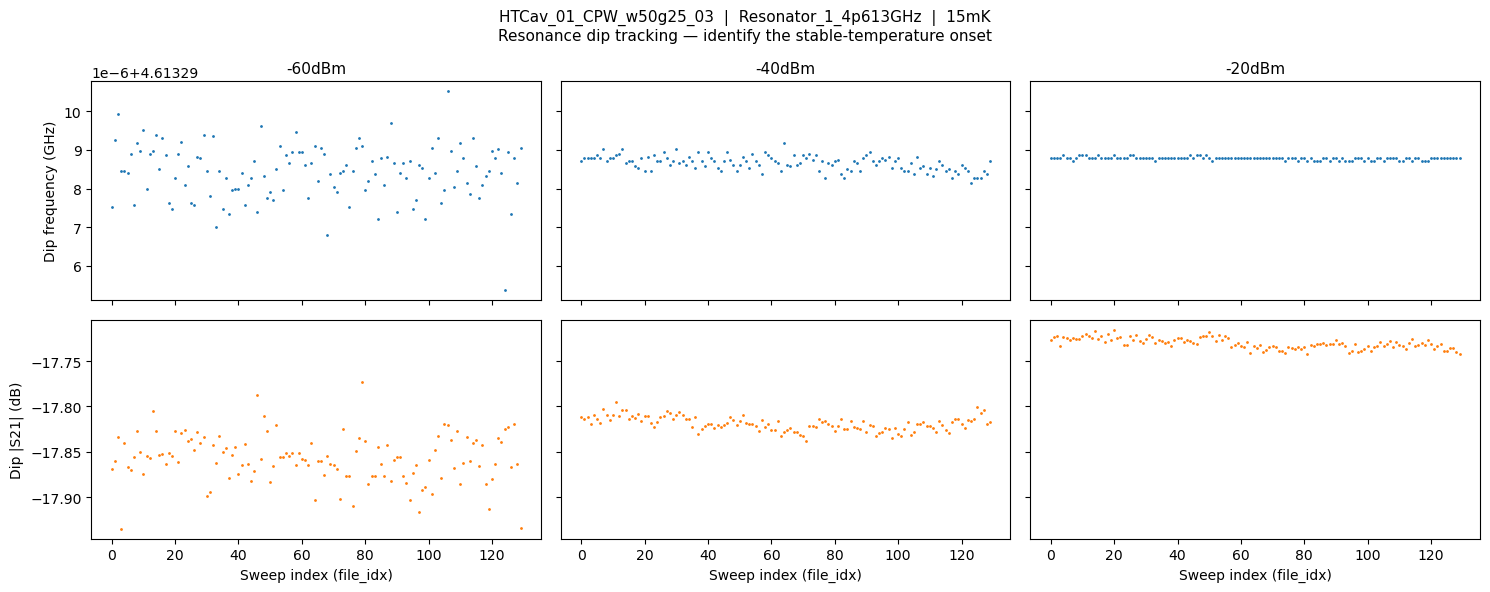


→ Inspect the plot above, then set 'trim_start_index' in the next cell.


In [8]:
# Plot dip frequency and dip |S21| vs sweep index
#
# Top row  : dip frequency (GHz) — sensitive to temperature drift
# Bottom row: dip |S21| (dB)     — sensitive to coupling / loss changes

n_pwr = len(all_powers)
fig, axes = plt.subplots(2, n_pwr,
                         figsize=(max(5 * n_pwr, 8), 6),
                         sharex='col', sharey='row')
axes = np.atleast_2d(axes).reshape(2, n_pwr)   # ensure 2-D even for 1 power

for col, pwr in enumerate(all_powers):
    d  = dip_data[pwr]
    xi = d['sweep_indices']

    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ax_top.plot(xi, d['dip_freqs_GHz'], '.', ms=2, color='C0')
    ax_bot.plot(xi, d['dip_mags_dB'],  '.', ms=2, color='C1')

    ax_top.set_title(pwr, fontsize=11)
    ax_bot.set_xlabel("Sweep index (file_idx)")

axes[0, 0].set_ylabel("Dip frequency (GHz)")
axes[1, 0].set_ylabel("Dip |S21| (dB)")

fig.suptitle(
    f"{sample_name}  |  {res_label}_{freq_str}  |  {temperature}\n"
    "Resonance dip tracking — identify the stable-temperature onset",
    fontsize=11
)
fig.tight_layout()
plt.show()

print("\n→ Inspect the plot above, then set 'trim_start_index' in the next cell.")

In [9]:
# Set trim start index
#
# After viewing the dip plot above, set the file_idx from which all
# temperatures are stable.  Sweeps BELOW this index are discarded.
# The same index is applied to every power group.

trim_start_index = 0   # UPDATE!!! 

print(f"trim_start_index = {trim_start_index}")
for pwr in all_powers:
    n_total   = len(power_groups[pwr])
    n_kept    = n_total - trim_start_index
    n_discarded = trim_start_index
    print(f"  {pwr:>10s} : keep {n_kept}/{n_total}  "
          f"(discard first {n_discarded} sweeps)")

trim_start_index = 0
      -60dBm : keep 130/130  (discard first 0 sweeps)
      -40dBm : keep 130/130  (discard first 0 sweeps)
      -20dBm : keep 130/130  (discard first 0 sweeps)


In [10]:
# Copy trimmed files to a new directory
#
# Trimmed files are re-indexed from 0 within each power group.
# A new metadata_trimmed.csv records the time of each trimmed sweep:
#   time_s = trimmed_file_index × sweep_duration   (relative to trim point)

trimmed_dir = target_dir / f"{res_label}_{freq_str}_trimmed"
trimmed_dir.mkdir(parents=True, exist_ok=True)

trimmed_meta_rows = []

for pwr in all_powers:
    trimmed_idx = 0
    for orig_idx, entry in enumerate(power_groups[pwr]):
        if orig_idx < trim_start_index:
            continue

        src_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{orig_idx}.csv"
        dst_name = f"{sample_name}_{freq_str}_{pwr}_{temperature}_{trimmed_idx}.csv"
        shutil.copy2(organized_dir / src_name, trimmed_dir / dst_name)

        trimmed_meta_rows.append({
            'power_str'          : pwr,
            'trimmed_file_index' : trimmed_idx,
            'orig_file_index'    : orig_idx,
            'sweep_index' : entry['file_index'],
            'unix_time' : entry['mtime'],
            'time_s'             : trimmed_idx * sweep_duration,
            'filename'           : dst_name,
        })
        trimmed_idx = trimmed_idx + 1

trimmed_meta_df = pd.DataFrame(trimmed_meta_rows)
trimmed_meta_df.to_csv(trimmed_dir / "metadata_trimmed.csv", index=False)

print(f"Trimmed files saved to: {trimmed_dir}")
print()
print(trimmed_meta_df.groupby('power_str')['trimmed_file_index'].count()
      .rename('n_sweeps_kept').to_string())

Trimmed files saved to: C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_78_Line1-HTCav_01_CPW_w50g25_03\Resonator_1_4p613GHz_trimmed

power_str
-20dBm    130
-40dBm    130
-60dBm    130
